In [46]:
# ============================================================
# CELL 1 - IMPORT & GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# ============================================================
# CELL 2 - DATASET PATH
# ============================================================

dataset_path = "/content/drive/MyDrive/Colab Notebooks/CNN-data bird & butterfly/data_bird_butterfly"

if dataset_path == "FIX_ME":
    print("[BELUM LENGKAP] Gantikan dataset_path dengan lokasi folder sebenar.")
else:
    train_dir = dataset_path + "/train"
    test_dir = dataset_path + "/test"

    print("Train folder exists:", os.path.exists(train_dir))
    print("Test folder exists :", os.path.exists(test_dir))

    if os.path.exists(train_dir):
        print("Train classes:", os.listdir(train_dir))

    if os.path.exists(test_dir):
        print("Test classes :", os.listdir(test_dir))

Train folder exists: True
Test folder exists : True
Train classes: ['bird', 'butterfly']
Test classes : ['bird', 'butterfly']


In [48]:
# ============================================================
# CELL 3 - DEVICE + IMAGE TRANSFORMS
# ============================================================

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Peranti digunakan:", device)

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

print("[SEDIA] Image transforms telah ditetapkan.")

Peranti digunakan: cpu
[SEDIA] Image transforms telah ditetapkan.


In [49]:
# ============================================================
# CELL 4 - LOAD DATASET
# ============================================================

if "train_dir" not in globals() or "test_dir" not in globals():
    print("[BELUM SEDIA] Lengkapkan dataset_path dahulu.")
    train_dataset = test_dataset = None
else:
    train_dataset = datasets.ImageFolder(
        root=train_dir,
        transform=train_transform
    )

    test_dataset = datasets.ImageFolder(
        root=test_dir,
        transform=test_transform
    )

    print("Class names     :", train_dataset.classes)
    print("Class mapping   :", train_dataset.class_to_idx)
    print("Training images :", len(train_dataset))
    print("Testing images  :", len(test_dataset))

Class names     : ['bird', 'butterfly']
Class mapping   : {'bird': 0, 'butterfly': 1}
Training images : 38
Testing images  : 36


Batch image shape: torch.Size([16, 3, 64, 64])
Batch label shape: torch.Size([16])


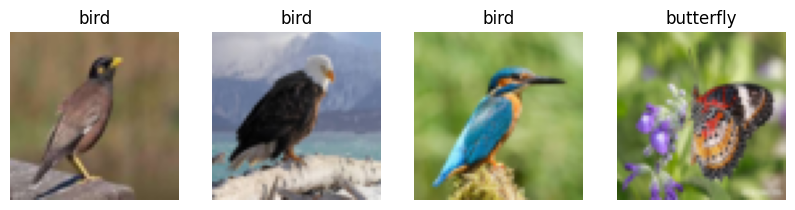

In [50]:
# ============================================================
# CELL 5 - DATALOADER + CONTOH DATASET
# ============================================================

if train_dataset is None or test_dataset is None:
    print("[BELUM SEDIA] Load dataset dahulu.")
    train_loader = test_loader = None
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    images, labels = next(iter(train_loader))

    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

    plt.figure(figsize=(10, 4))

    for i in range(min(4, len(images))):
        image = images[i].permute(1, 2, 0)
        class_name = train_dataset.classes[labels[i].item()]

        plt.subplot(1, 4, i + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

    plt.show()

In [51]:
# ============================================================
# CELL 6 - MODEL CNN
# ============================================================

INPUT_CHANNELS = 3
OUTPUT_CLASSES = 2

class BirdButterflyCNN(nn.Module):

    def __init__(self):
        super().__init__()

        if INPUT_CHANNELS is None or OUTPUT_CLASSES is None:
            raise ValueError(
                "Lengkapkan INPUT_CHANNELS dan OUTPUT_CLASSES dahulu."
            )

        self.features = nn.Sequential(
            nn.Conv2d(INPUT_CHANNELS, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, OUTPUT_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

try:
    model = BirdButterflyCNN().to(device)
    print(model)
except Exception as e:
    model = None
    print("[BELUM LENGKAP]", e)

BirdButterflyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [52]:
# ============================================================
# CELL 7 - LOSS FUNCTION, OPTIMIZER & EPOCH
# ============================================================

if model is None:
    print("[BELUM SEDIA] Lengkapkan model dahulu.")
    criterion = optimizer = epochs = None
else:
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epochs = 3

    if criterion is None or optimizer is None or epochs is None:
        print(
            "[BELUM LENGKAP] Lengkapkan criterion, optimizer dan epochs."
        )

In [53]:
# ============================================================
# CELL 8 - TRAINING MODEL
# ============================================================

if (
    model is None
    or train_loader is None
    or criterion is None
    or optimizer is None
    or epochs is None
):
    print(
        "[BELUM SEDIA] Lengkapkan dataset, model dan training setup dahulu."
    )
    training_complete = False
else:
    # Tambahan untuk simpan Loss dan Accuracy
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total if total else 0

        # Tambahan untuk simpan nilai
        train_losses.append(running_loss)
        train_accuracies.append(accuracy)

        print(
            f"Epoch {epoch+1}/{epochs}: "
            f"Loss={running_loss:.4f}, "
            f"Accuracy={accuracy:.4f}"
        )

    training_complete = True

Epoch 1/3: Loss=1.9012, Accuracy=0.7895
Epoch 2/3: Loss=1.7627, Accuracy=0.7895
Epoch 3/3: Loss=1.6732, Accuracy=0.7895


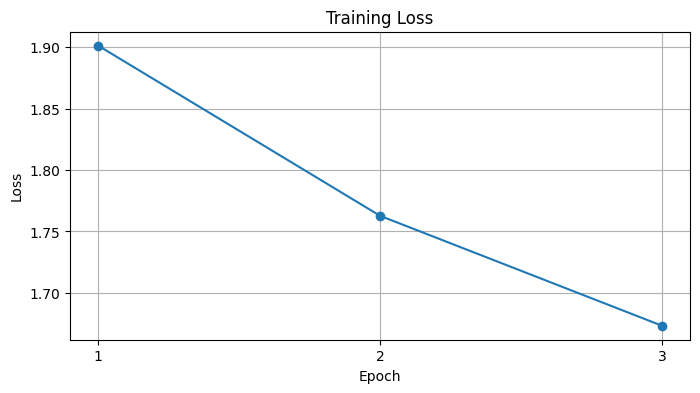

In [54]:
# ============================================================
# CELL 9 - GRAF TRAINING LOSS
# ============================================================

if globals().get("training_complete", False):
    plt.figure(figsize=(8, 4))

    plt.plot(
        range(1, epochs + 1),
        train_losses,
        marker='o'
    )

    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)
    plt.show()
else:
    print("[BELUM SEDIA] Train model dahulu.")

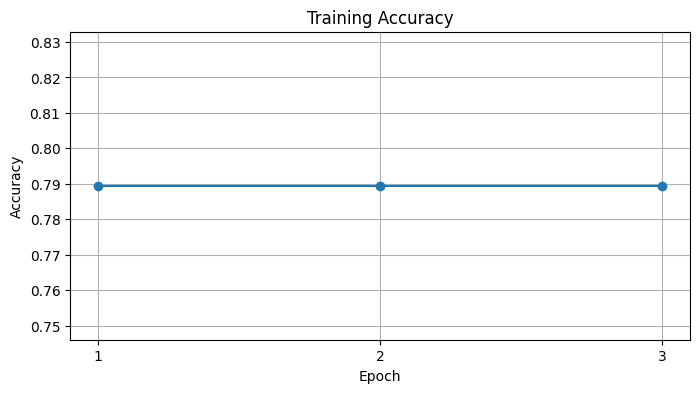

In [55]:
# ============================================================
# CELL 10 - GRAF TRAINING ACCURACY
# ============================================================

if globals().get("training_complete", False):
    plt.figure(figsize=(8, 4))

    plt.plot(
        range(1, epochs + 1),
        train_accuracies,
        marker='o'
    )

    plt.title("Training Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(range(1, epochs + 1))
    plt.grid(True)
    plt.show()
else:
    print("[BELUM SEDIA] Train model dahulu.")

Test Accuracy: 0.8333


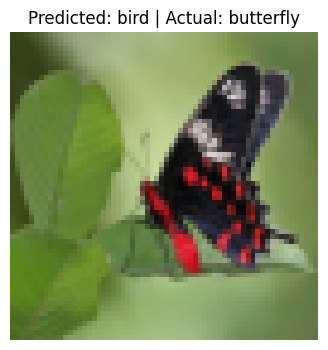

Predicted: bird
Actual   : butterfly


In [56]:
# ============================================================
# CELL 11 - TEST ACCURACY + PREDICTION
# ============================================================

if not globals().get("training_complete", False):
    print("[BELUM SEDIA] Train model dahulu.")
else:
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_accuracy = correct / total if total else 0

    print(
        "Test Accuracy:",
        f"{test_accuracy:.4f}"
    )

    # Cari gambar butterfly
    for i in range(len(test_dataset)):
        image, actual_label = test_dataset[i]

        if test_dataset.classes[actual_label] == "butterfly":
            break

    with torch.no_grad():
        output = model(
            image.unsqueeze(0).to(device)
        )

        predicted_label = torch.argmax(
            output,
            dim=1
        ).item()

    predicted_class = test_dataset.classes[predicted_label]
    actual_class = test_dataset.classes[actual_label]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.permute(1, 2, 0))
    plt.title(
        f"Predicted: {predicted_class} | "
        f"Actual: {actual_class}"
    )
    plt.axis("off")
    plt.show()

    print("Predicted:", predicted_class)
    print("Actual   :", actual_class)

In [57]:
# ============================================================
# CELL 12 - SIMPAN MODEL
# ============================================================

save_dir = "/content/drive/MyDrive/Colab Notebooks"

save_path = os.path.join(
    save_dir,
    "bird_butterfly_cnn_model.pth"
)

if globals().get("training_complete", False):
    os.makedirs(save_dir, exist_ok=True)

    torch.save(
        model.state_dict(),
        save_path
    )

    print(
        "Model disimpan sebagai:",
        save_path
    )
else:
    print(
        "Model belum disimpan kerana training_complete masih False."
    )

Model disimpan sebagai: /content/drive/MyDrive/Colab Notebooks/bird_butterfly_cnn_model.pth


In [58]:
# ============================================================
# CELL 13 - HYPERPARAMETER TUNING
# ============================================================

learning_rates = [0.001, 0.01]
tuning_results = []

for lr in learning_rates:

    print("\n========================================")
    print("Learning Rate:", lr)
    print("========================================")

    tuning_model = BirdButterflyCNN().to(device)

    tuning_criterion = nn.CrossEntropyLoss()

    tuning_optimizer = optim.Adam(
        tuning_model.parameters(),
        lr=lr
    )

    tuning_epochs = 3

    for epoch in range(tuning_epochs):

        tuning_model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            tuning_optimizer.zero_grad()

            outputs = tuning_model(images)

            loss = tuning_criterion(outputs, labels)

            loss.backward()

            tuning_optimizer.step()

            predicted = torch.argmax(outputs, dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = correct / total if total else 0

        print(
            f"Epoch {epoch+1}/{tuning_epochs}: "
            f"Accuracy={accuracy:.4f}"
        )

    tuning_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = tuning_model(images)

            predicted = torch.argmax(outputs, dim=1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total if total else 0

    tuning_results.append({
        "Learning Rate": lr,
        "Test Accuracy": test_acc
    })

    print(
        f"Test Accuracy untuk learning rate {lr}: "
        f"{test_acc:.4f}"
    )


Learning Rate: 0.001
Epoch 1/3: Accuracy=0.7895
Epoch 2/3: Accuracy=0.7895
Epoch 3/3: Accuracy=0.7895
Test Accuracy untuk learning rate 0.001: 0.8333

Learning Rate: 0.01
Epoch 1/3: Accuracy=0.4211
Epoch 2/3: Accuracy=0.5789
Epoch 3/3: Accuracy=0.7895
Test Accuracy untuk learning rate 0.01: 0.8333


In [59]:
# ============================================================
# CELL 14 - PERBANDINGAN HYPERPARAMETER
# ============================================================

print("========================================")
print("HASIL HYPERPARAMETER TUNING")
print("========================================")

for result in tuning_results:
    print(
        f"Learning Rate: {result['Learning Rate']} "
        f"| Test Accuracy: {result['Test Accuracy']:.4f}"
    )

HASIL HYPERPARAMETER TUNING
Learning Rate: 0.001 | Test Accuracy: 0.8333
Learning Rate: 0.01 | Test Accuracy: 0.8333


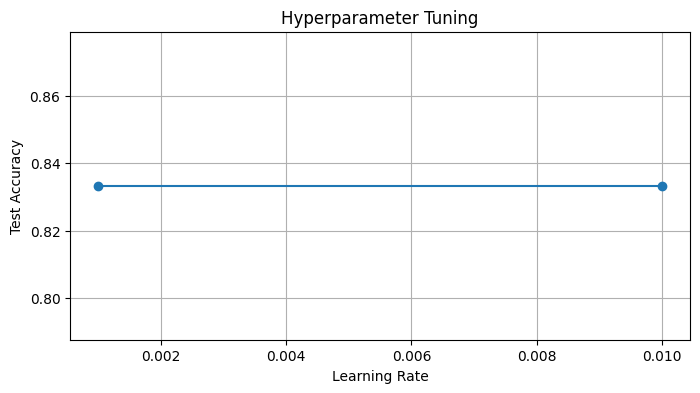

In [60]:
# ============================================================
# CELL 15 - GRAF HYPERPARAMETER TUNING
# ============================================================

learning_rate_values = [
    result["Learning Rate"]
    for result in tuning_results
]

accuracy_values = [
    result["Test Accuracy"]
    for result in tuning_results
]

plt.figure(figsize=(8, 4))

plt.plot(
    learning_rate_values,
    accuracy_values,
    marker='o'
)

plt.title("Hyperparameter Tuning")
plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.grid(True)

plt.show()

In [61]:
# ============================================================
# CELL 16 - DEPLOYMENT / PREDICTION FUNCTION
# ============================================================

def predict_image(image_path, model, class_names):

    from PIL import Image

    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        predicted_label = torch.argmax(output, dim=1).item()

    predicted_class = class_names[predicted_label]

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()

    print("Predicted class:", predicted_class)

    return predicted_class

In [62]:
# ============================================================
# CELL 17 - UPLOAD IMAGE
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving 23.jfif to 23.jfif


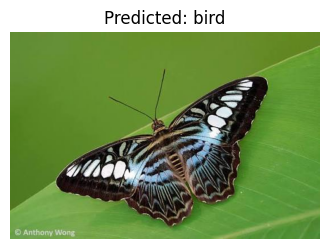

Predicted class: bird


In [63]:
# ============================================================
# CELL 18 - RUN PREDICTION
# ============================================================

image_path = list(uploaded.keys())[0]

predicted_class = predict_image(
    image_path,
    model,
    test_dataset.classes
)

In [64]:
# ============================================================
# CELL 19 - DEPLOYMENT RESULT
# ============================================================

print("========================================")
print("DEPLOYMENT RESULT")
print("========================================")

print("Image file      :", image_path)
print("Predicted class :", predicted_class)
print("Available class :", test_dataset.classes)

DEPLOYMENT RESULT
Image file      : 23.jfif
Predicted class : bird
Available class : ['bird', 'butterfly']
